# 🤖🧠 AI vs Human Text Detection (NLP + Stylometry + Deep Learning)

Welcome! This notebook builds an end-to-end pipeline to classify text as:

- ✅ **Human-written** (label `0`)
- ✅ **AI-generated** (label `1`)

We will go beyond basic NLP by adding **Stylometric Analysis** (author-style signals) such as:
- ✍️ Sentence length + variance
- 📚 Vocabulary richness
- 🔁 Repetition patterns
- ✅ Grammar consistency (lightweight proxies)

---

## 🔗 Connect with me
- 🧑‍💻 Kaggle: https://www.kaggle.com/your_handle  
- 🐦 X/Twitter: https://twitter.com/your_handle  
- 💼 LinkedIn: https://www.linkedin.com/in/your_handle  
- 🌐 GitHub: https://github.com/your_handle  

---

## 📌 Dataset
**Columns**
- `text`: the document / essay / snippet
- `generated`: binary label (`1` = AI, `0` = Human)

Let's dive in! 🚀

## 🧰 Code Cell — Imports + Global Style (single theme color)

In [1]:
import os
import re
import gc
import math
import string
import numpy as np
import pandas as pd

from collections import Counter
from dataclasses import dataclass

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report
)

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

# Optional (stylometry extras)
import nltk

# Download punkt safely for Kaggle
try:
    nltk.data.find("tokenizers/punkt")
except LookupError:
    nltk.download("punkt")

THEME = "#5B8DEF"   # Single color theme
BG = "#0b0f19"      # dark-ish background for dashboard look (optional)
FG = "#E8EEF9"      # foreground text color
GRID = "#233044"

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.edgecolor"] = GRID
plt.rcParams["axes.labelcolor"] = FG
plt.rcParams["xtick.color"] = FG
plt.rcParams["ytick.color"] = FG
plt.rcParams["text.color"] = FG

sns.set_theme(style="darkgrid")
sns.set(rc={
    "axes.facecolor": BG,
    "figure.facecolor": BG,
    "grid.color": GRID
})

## 📥 Load Dataset (CSV)

Upload your CSV to Kaggle dataset/input, then set the path below.
We will:
- Drop nulls
- Ensure correct dtypes
- Create helpful columns for EDA

## 📥 Code Cell — Load CSV + Basic Cleanup

In [3]:
df = pd.read_csv('AI_Human.csv')
print(df.shape)
df.head()

(487235, 2)


,text,generated
0,Cars. Cars have been around since they became ...,0.0
1,Transportation is a large necessity in most co...,0.0
2,"""America's love affair with it's vehicles seem...",0.0
3,How often do you ride in a car? Do you drive a...,0.0
4,Cars are a wonderful thing. They are perhaps o...,0.0


In [ ]:
# Set your CSV path here
DATA_PATH = "/kaggle/input/your-dataset-folder/ai_vs_human.csv"

df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

In [4]:
# Validate columns
required_cols = {"text", "generated"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing columns: {missing}. Found columns: {list(df.columns)}")

df = df[["text", "generated"]].copy()
df["text"] = df["text"].astype(str)
df["generated"] = df["generated"].astype(int)

# Drop empty-like rows
df["text"] = df["text"].str.strip()
df = df[df["text"].str.len() > 0].dropna()

print("After cleanup:", df.shape)
df["generated"].value_counts()

After cleanup: (487231, 2)


generated
0    305797
1    181434
Name: count, dtype: int64

## 📊 Class Balance

We want to ensure AI vs Human distribution is reasonable and understand imbalance.

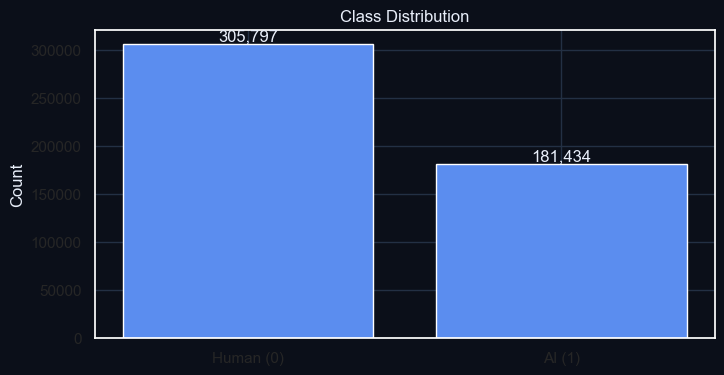

In [5]:
counts = df["generated"].value_counts().sort_index()
labels = ["Human (0)", "AI (1)"]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels, counts.values, color=THEME, edgecolor="white")
ax.set_title("Class Distribution", color=FG)
ax.set_ylabel("Count", color=FG)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height(), f"{int(b.get_height()):,}",
            ha="center", va="bottom", color=FG)
plt.show()

## 🧹 Text Preprocessing

We keep preprocessing **minimal** to preserve stylistic signals for stylometry.
- Lowercasing (optional for models)
- Remove excessive whitespace
- Keep punctuation for stylometry (we’ll also create a "clean" version for TF-IDF)

In [6]:
def normalize_whitespace(text: str) -> str:
    return re.sub(r"\s+", " ", text).strip()

def basic_clean(text: str) -> str:
    # Clean version for TF-IDF / BoW
    text = text.lower()
    text = normalize_whitespace(text)
    return text

df["text_raw"] = df["text"].apply(normalize_whitespace)
df["text_clean"] = df["text_raw"].apply(basic_clean)

df[["text_raw", "text_clean", "generated"]].head()

,text_raw,text_clean,generated
0,Cars. Cars have been around since they became ...,cars. cars have been around since they became ...,0
1,Transportation is a large necessity in most co...,transportation is a large necessity in most co...,0
2,"""America's love affair with it's vehicles seem...","""america's love affair with it's vehicles seem...",0
3,How often do you ride in a car? Do you drive a...,how often do you ride in a car? do you drive a...,0
4,Cars are a wonderful thing. They are perhaps o...,cars are a wonderful thing. they are perhaps o...,0


## 📊 Exploratory Data Analysis (EDA)

We compare AI vs Human using:
- 🧵 Character and word lengths
- 🧠 Stopword usage
- 🔥 Top words
- 🧩 N-grams (phrases)

In [7]:
def word_count(text: str) -> int:
    return len(text.split())

df["char_len"] = df["text_raw"].str.len()
df["word_len"] = df["text_raw"].apply(word_count)

df.groupby("generated")[["char_len", "word_len"]].describe().round(2)

char_len                                                          \
              count     mean      std   min     25%     50%     75%     max   
generated                                                                     
0          305797.0  2347.77  1079.03  73.0  1537.0  2150.0  2912.0  9174.0   
1          181434.0  2120.33   785.58   1.0  1647.0  2042.5  2474.0  8831.0   

           word_len                                                     
              count    mean     std   min    25%    50%    75%     max  
generated                                                               
0          305797.0  421.99  186.87  14.0  281.0  389.0  520.0  1668.0  
1          181434.0  344.41  117.02   1.0  274.0  337.0  403.0  1238.0

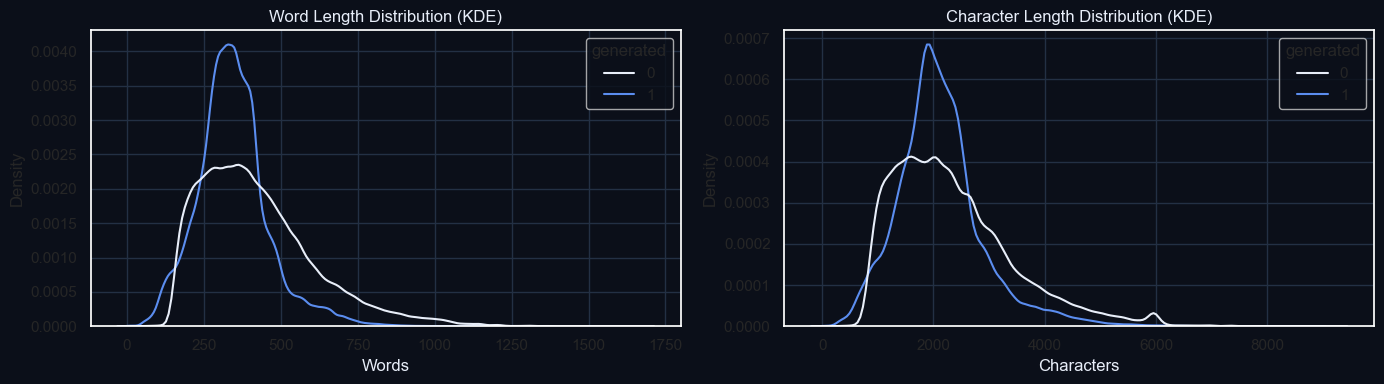

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.kdeplot(data=df, x="word_len", hue="generated", ax=axes[0],
            palette=[FG, THEME], common_norm=False)
axes[0].set_title("Word Length Distribution (KDE)", color=FG)
axes[0].set_xlabel("Words", color=FG)

sns.kdeplot(data=df, x="char_len", hue="generated", ax=axes[1],
            palette=[FG, THEME], common_norm=False)
axes[1].set_title("Character Length Distribution (KDE)", color=FG)
axes[1].set_xlabel("Characters", color=FG)

plt.tight_layout()
plt.show()

C:\Users\Hammad\AppData\Local\Temp\ipykernel_15052\2597214568.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="generated", y="stopword_ratio",


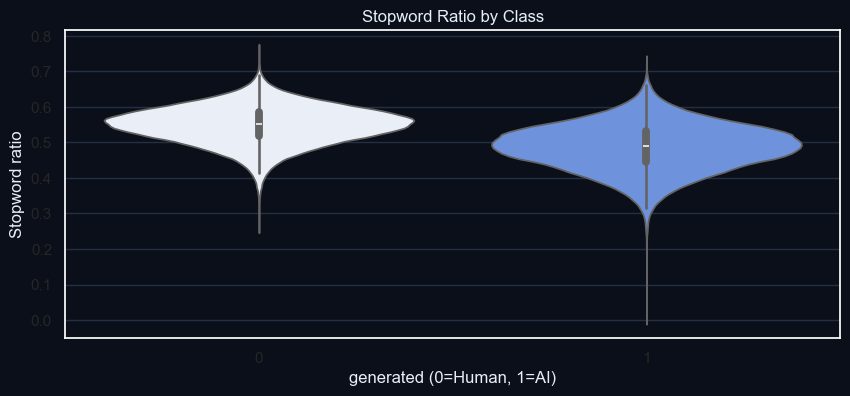

In [9]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

STOP = set(ENGLISH_STOP_WORDS)

def stopword_ratio(text: str) -> float:
    tokens = re.findall(r"[a-zA-Z']+", text.lower())
    if not tokens:
        return 0.0
    sw = sum(t in STOP for t in tokens)
    return sw / len(tokens)

df["stopword_ratio"] = df["text_raw"].apply(stopword_ratio)

fig, ax = plt.subplots(figsize=(10, 4))
sns.violinplot(data=df, x="generated", y="stopword_ratio",
               palette=[FG, THEME], ax=ax)
ax.set_title("Stopword Ratio by Class", color=FG)
ax.set_xlabel("generated (0=Human, 1=AI)", color=FG)
ax.set_ylabel("Stopword ratio", color=FG)
plt.show()

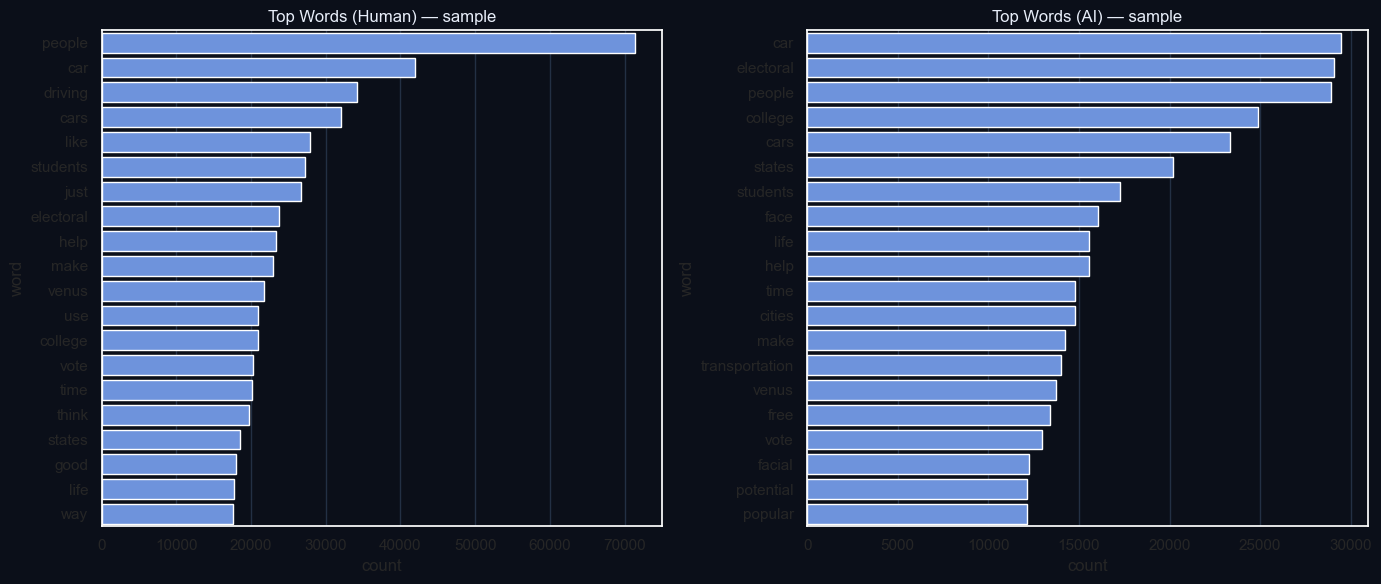

In [10]:
def top_words(texts, n=20):
    tokens = []
    for t in texts:
        toks = re.findall(r"[a-zA-Z']+", t.lower())
        tokens.extend([x for x in toks if x not in STOP and len(x) > 2])
    return Counter(tokens).most_common(n)

top_h = top_words(df.loc[df.generated==0, "text_raw"].head(20000), n=20)
top_a = top_words(df.loc[df.generated==1, "text_raw"].head(20000), n=20)

top_h_df = pd.DataFrame(top_h, columns=["word", "count"])
top_a_df = pd.DataFrame(top_a, columns=["word", "count"])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(data=top_h_df, y="word", x="count", color=THEME, ax=axes[0])
axes[0].set_title("Top Words (Human) — sample", color=FG)
sns.barplot(data=top_a_df, y="word", x="count", color=THEME, ax=axes[1])
axes[1].set_title("Top Words (AI) — sample", color=FG)

plt.tight_layout()
plt.show()

In [11]:
def top_ngrams_tfidf(texts, ngram_range=(2,2), top_n=20, max_features=200000):
    vec = TfidfVectorizer(ngram_range=ngram_range, max_features=max_features, min_df=2)
    X = vec.fit_transform(texts)
    scores = np.asarray(X.mean(axis=0)).ravel()
    idx = np.argsort(scores)[::-1][:top_n]
    inv = {v:k for k,v in vec.vocabulary_.items()}
    return [(inv[i], scores[i]) for i in idx if i in inv]

human_phrases = top_ngrams_tfidf(df.loc[df.generated==0, "text_clean"].head(50000), (2,2), 20)
ai_phrases = top_ngrams_tfidf(df.loc[df.generated==1, "text_clean"].head(50000), (2,2), 20)

pd.DataFrame(human_phrases, columns=["bigram", "avg_tfidf"]).head(10), pd.DataFrame(ai_phrases, columns=["bigram", "avg_tfidf"]).head(10)

(              bigram  avg_tfidf
 0  electoral college   0.019902
 1      the electoral   0.019528
 2             of the   0.018218
 3             in the   0.017306
 4              to do   0.012547
 5              to be   0.011937
 6              it is   0.011776
 7           would be   0.011471
 8             to the   0.010660
 9             on the   0.010560,
               bigram  avg_tfidf
 0      the electoral   0.025470
 1  electoral college   0.024827
 2             of the   0.020359
 3           the face   0.018209
 4    driverless cars   0.016049
 5             in the   0.015206
 6            on mars   0.012824
 7           car free   0.012430
 8              it is   0.012384
 9           that the   0.012308)

## 🧠 Stylometry (Author Style Signals)

These features often capture differences like:
- AI tends to be more uniform in sentence length
- Humans can be more bursty / irregular
- AI may show more templated phrasing or repeated patterns

We'll compute:
- Sentence length stats (mean, std)
- Vocabulary richness (type-token ratio, MTLD-like proxy)
- Repetition (unique n-gram ratio)
- Grammar consistency proxies (punctuation patterns, POS-lite heuristics)

In [12]:
import nltk
from nltk.tokenize import sent_tokenize

def safe_sent_tokenize(text: str):
    # nltk sentence tokenizer can fail rarely on very weird input; guard it
    try:
        sents = sent_tokenize(text)
        return [s.strip() for s in sents if s.strip()]
    except Exception:
        # fallback: naive split
        return [s.strip() for s in re.split(r"[.!?]+", text) if s.strip()]

def tokens_alpha(text: str):
    return re.findall(r"[A-Za-z']+", text)

def type_token_ratio(tokens):
    if not tokens:
        return 0.0
    return len(set(tokens)) / len(tokens)

def avg_word_len(tokens):
    if not tokens:
        return 0.0
    return float(np.mean([len(t) for t in tokens]))

def sentence_word_lengths(text: str):
    sents = safe_sent_tokenize(text)
    if not sents:
        return (0.0, 0.0, 0.0, 0)
    lens = [len(tokens_alpha(s)) for s in sents]
    lens = [l for l in lens if l > 0]
    if not lens:
        return (0.0, 0.0, 0.0, len(sents))
    return (float(np.mean(lens)), float(np.std(lens)), float(np.max(lens)), len(lens))

def repeated_ngram_ratio(text: str, n=3):
    toks = [t.lower() for t in tokens_alpha(text)]
    if len(toks) < n:
        return 0.0
    grams = [" ".join(toks[i:i+n]) for i in range(len(toks)-n+1)]
    if not grams:
        return 0.0
    c = Counter(grams)
    repeated = sum(v for v in c.values() if v > 1)
    return repeated / len(grams)

def punctuation_rate(text: str):
    if not text:
        return 0.0
    punct = sum(ch in string.punctuation for ch in text)
    return punct / len(text)

def uppercase_ratio(text: str):
    if not text:
        return 0.0
    upp = sum(ch.isupper() for ch in text)
    alpha = sum(ch.isalpha() for ch in text)
    return (upp / alpha) if alpha else 0.0

def stylometry_features(text: str) -> dict:
    text = normalize_whitespace(text)
    toks = [t.lower() for t in tokens_alpha(text)]
    ttr = type_token_ratio(toks)

    sent_mean, sent_std, sent_max, n_sents = sentence_word_lengths(text)

    feats = {
        "word_len": len(text.split()),
        "char_len": len(text),
        "n_sents": n_sents,
        "sent_len_mean": sent_mean,
        "sent_len_std": sent_std,
        "sent_len_max": sent_max,
        "ttr": ttr,
        "avg_word_len": avg_word_len(toks),
        "repeated_trigram_ratio": repeated_ngram_ratio(text, n=3),
        "punct_rate": punctuation_rate(text),
        "uppercase_ratio": uppercase_ratio(text),
        "comma_per_1000c": (text.count(",") / max(1, len(text))) * 1000.0,
        "semicolon_per_1000c": (text.count(";") / max(1, len(text))) * 1000.0,
        "exclam_per_1000c": (text.count("!") / max(1, len(text))) * 1000.0,
        "question_per_1000c": (text.count("?") / max(1, len(text))) * 1000.0,
    }
    return feats

# Compute stylometry (vectorized-ish via apply; for 500k rows it's still OK but can take time)
# If you want speed, you can sample or use swifter; here we keep it Kaggle-safe.
sty = df["text_raw"].apply(stylometry_features)
sty_df = pd.DataFrame(list(sty))
sty_df["generated"] = df["generated"].values
sty_df.head()

,word_len,char_len,n_sents,sent_len_mean,sent_len_std,sent_len_max,ttr,avg_word_len,repeated_trigram_ratio,punct_rate,uppercase_ratio,comma_per_1000c,semicolon_per_1000c,exclam_per_1000c,question_per_1000c,generated
0,584,3286,23,25.260870,13.724676,54.0,0.461274,4.506024,0.094991,0.022824,0.022562,12.172855,0.0,0.000000,0.000000,0
1,462,2734,27,16.888889,6.390579,34.0,0.502193,4.820175,0.024229,0.023409,0.020976,8.778347,0.0,0.000000,0.365764,0
2,744,4424,48,15.458333,5.755281,30.0,0.435310,4.835580,0.070270,0.022830,0.017318,6.555154,0.0,0.000000,0.000000,0
3,686,4011,47,14.595745,8.115285,36.0,0.508746,4.683673,0.005848,0.030915,0.024055,9.473947,0.0,0.997258,1.745201,0
4,871,4695,50,17.180000,8.296240,36.0,0.369034,4.316647,0.094516,0.023429,0.019978,7.454739,0.0,0.000000,0.212993,0


In [13]:
feat_cols = [c for c in sty_df.columns if c != "generated"]

summary = sty_df.groupby("generated")[feat_cols].mean().T
summary.columns = ["Human_mean", "AI_mean"]
summary["diff_AI_minus_Human"] = summary["AI_mean"] - summary["Human_mean"]
summary.sort_values("diff_AI_minus_Human", ascending=False).head(15)

,Human_mean,AI_mean,diff_AI_minus_Human
comma_per_1000c,6.472520,9.739202,3.266682
avg_word_len,4.432861,4.995700,0.562839
exclam_per_1000c,0.134554,0.241353,0.106799
repeated_trigram_ratio,0.097300,0.166627,0.069326
ttr,0.440700,0.476008,0.035309
punct_rate,0.020865,0.022174,0.001310
uppercase_ratio,0.031400,0.025338,-0.006062
semicolon_per_1000c,0.090308,0.035177,-0.055131
question_per_1000c,0.358587,0.190544,-0.168043
sent_len_mean,21.856167,19.383524,-2.472643


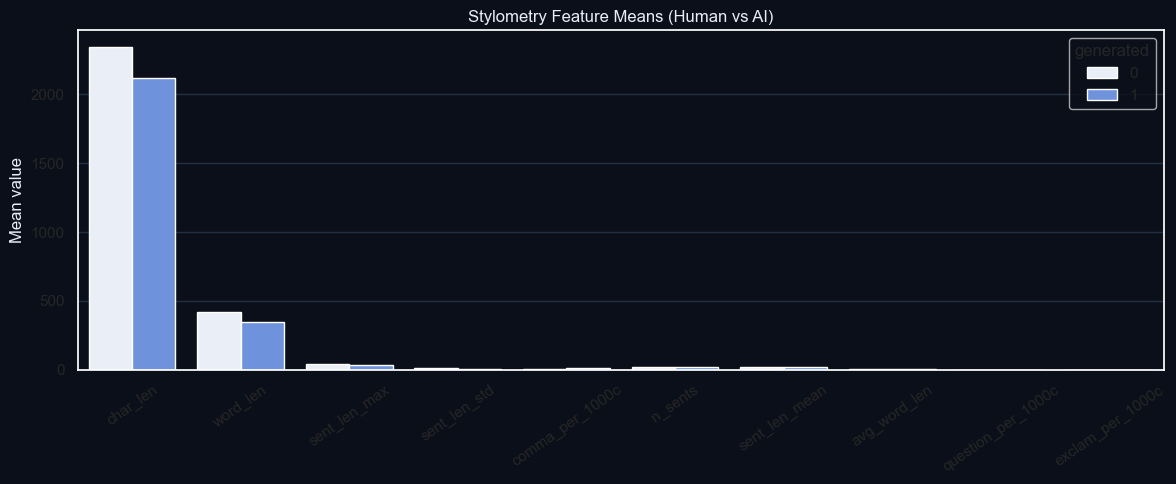

In [14]:
# Plot a subset of the most discriminative stylometry means
topk = 10
top_feats = summary["diff_AI_minus_Human"].abs().sort_values(ascending=False).head(topk).index.tolist()

plot_df = sty_df.melt(id_vars="generated", value_vars=top_feats,
                      var_name="feature", value_name="value")

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=plot_df, x="feature", y="value", hue="generated",
            palette=[FG, THEME], ax=ax, estimator=np.mean, errorbar=None)
ax.set_title("Stylometry Feature Means (Human vs AI)", color=FG)
ax.set_xlabel("")
ax.set_ylabel("Mean value", color=FG)
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

## 🧪 Train/Test Split

We use stratified splitting so both classes are represented fairly in train and test.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text_clean"], df["generated"],
    test_size=0.2, random_state=42, stratify=df["generated"]
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (389784,) Test: (97447,)


## 🧱 Feature Engineering + Classic Models

We will train:
- ✅ Logistic Regression (strong baseline for text)
- ✅ Multinomial Naive Bayes (fast + solid)
- ✅ Random Forest (often weaker on sparse TF-IDF, but good as comparison)

**TF-IDF is required** ✅

In [16]:
def evaluate_model(name, model, X_test, y_test):
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    pr, rc, f1, _ = precision_recall_fscore_support(y_test, pred, average="binary", zero_division=0)
    cm = confusion_matrix(y_test, pred)

    print(f"\n=== {name} ===")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {pr:.4f}")
    print(f"Recall:    {rc:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print("\nConfusion Matrix:\n", cm)
    print("\nReport:\n", classification_report(y_test, pred, digits=4, zero_division=0))
    return {"model": name, "accuracy": acc, "precision": pr, "recall": rc, "f1": f1, "cm": cm}

In [17]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    max_features=300000,
    strip_accents="unicode"
)

logreg = LogisticRegression(
    max_iter=2000,
    n_jobs=-1,
    class_weight="balanced"
)

pipe_lr = Pipeline([
    ("tfidf", tfidf),
    ("clf", logreg)
])

pipe_lr.fit(X_train, y_train)
res_lr = evaluate_model("TF-IDF + LogisticRegression", pipe_lr, X_test, y_test)


=== TF-IDF + LogisticRegression ===
Accuracy:  0.9965
Precision: 0.9961
Recall:    0.9944
F1-score:  0.9952

Confusion Matrix:
 [[61019   141]
 [  204 36083]]

Report:
               precision    recall  f1-score   support

           0     0.9967    0.9977    0.9972     61160
           1     0.9961    0.9944    0.9952     36287

    accuracy                         0.9965     97447
   macro avg     0.9964    0.9960    0.9962     97447
weighted avg     0.9965    0.9965    0.9965     97447



In [18]:
pipe_nb = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=0.95, max_features=300000)),
    ("clf", MultinomialNB(alpha=0.5))
])

pipe_nb.fit(X_train, y_train)
res_nb = evaluate_model("TF-IDF + MultinomialNB", pipe_nb, X_test, y_test)


=== TF-IDF + MultinomialNB ===
Accuracy:  0.9804
Precision: 0.9855
Recall:    0.9614
F1-score:  0.9733

Confusion Matrix:
 [[60646   514]
 [ 1400 34887]]

Report:
               precision    recall  f1-score   support

           0     0.9774    0.9916    0.9845     61160
           1     0.9855    0.9614    0.9733     36287

    accuracy                         0.9804     97447
   macro avg     0.9815    0.9765    0.9789     97447
weighted avg     0.9804    0.9804    0.9803     97447



In [19]:
# RandomForest on sparse high-dim text is often not the best,
# but included as requested; we keep it constrained.
pipe_rf = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2), min_df=3, max_df=0.9, max_features=120000)),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2, 
        min_samples_leaf=1,
        n_jobs=-1,
        random_state=42
    ))
])

pipe_rf.fit(X_train, y_train)
res_rf = evaluate_model("TF-IDF + RandomForest", pipe_rf, X_test, y_test)


=== TF-IDF + RandomForest ===
Accuracy:  0.9992
Precision: 0.9997
Recall:    0.9982
F1-score:  0.9990

Confusion Matrix:
 [[61150    10]
 [   66 36221]]

Report:
               precision    recall  f1-score   support

           0     0.9989    0.9998    0.9994     61160
           1     0.9997    0.9982    0.9990     36287

    accuracy                         0.9992     97447
   macro avg     0.9993    0.9990    0.9992     97447
weighted avg     0.9992    0.9992    0.9992     97447



## 📊 Model Comparison

We compare Accuracy / Precision / Recall / F1 in a compact dashboard view.

In [20]:
results = pd.DataFrame([res_lr, res_nb, res_rf]).drop(columns=["cm"])
results

,model,accuracy,precision,recall,f1
0,TF-IDF + LogisticRegression,0.996460,0.996108,0.994378,0.995242
1,TF-IDF + MultinomialNB,0.980359,0.985481,0.961419,0.973301
2,TF-IDF + RandomForest,0.999220,0.999724,0.998181,0.998952


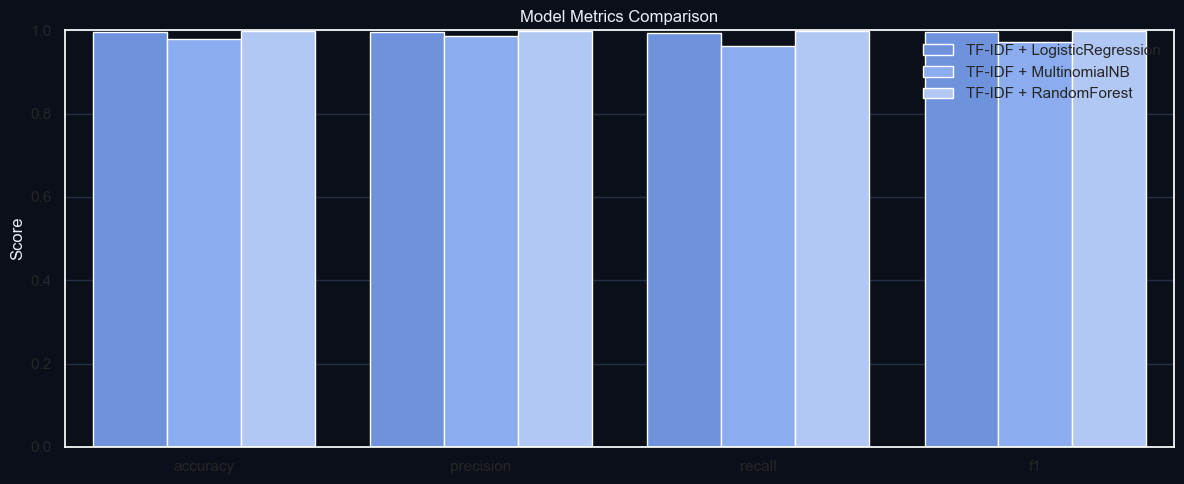

In [21]:
m = results.melt(id_vars="model", var_name="metric", value_name="value")

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=m, x="metric", y="value", hue="model", ax=ax,
            palette=[THEME, "#7aa7ff", "#a7c5ff"])
ax.set_ylim(0, 1)
ax.set_title("Model Metrics Comparison", color=FG)
ax.set_xlabel("")
ax.set_ylabel("Score", color=FG)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

## 🧠 Hybrid: TF-IDF + Stylometry

A practical "stand-out" approach:
- Use TF-IDF for semantic + phrasing signals
- Use stylometry for author-style signals

We'll concatenate TF-IDF with stylometry numeric features.

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.sparse import hstack, csr_matrix

class StylometryTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        feats = [stylometry_features(x) for x in X]
        df_feats = pd.DataFrame(feats).fillna(0.0)
        return df_feats.values

# Pipeline: TF-IDF (sparse) + stylometry (dense -> sparse) + logistic regression
tfidf_h = TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=0.95, max_features=250000)

class HybridVectorizer(BaseEstimator, TransformerMixin):
    def __init__(self, tfidf_vectorizer):
        self.tfidf_vectorizer = tfidf_vectorizer
        self.scaler = StandardScaler(with_mean=False)  # for sparse compatibility

    def fit(self, X, y=None):
        self.tfidf_vectorizer.fit(X)
        sty = StylometryTransformer().transform(X)
        self.scaler.fit(csr_matrix(sty))
        return self

    def transform(self, X):
        X_tfidf = self.tfidf_vectorizer.transform(X)
        sty = StylometryTransformer().transform(X)
        sty_scaled = self.scaler.transform(csr_matrix(sty))
        return hstack([X_tfidf, sty_scaled]).tocsr()

hybrid = Pipeline([
    ("hyb", HybridVectorizer(tfidf_h)),
    ("clf", LogisticRegression(max_iter=2000, n_jobs=-1, class_weight="balanced"))
])

hybrid.fit(X_train, y_train)
res_hybrid = evaluate_model("Hybrid (TF-IDF + Stylometry) + LogisticRegression", hybrid, X_test, y_test)


=== Hybrid (TF-IDF + Stylometry) + LogisticRegression ===
Accuracy:  0.9974
Precision: 0.9970
Recall:    0.9961
F1-score:  0.9966

Confusion Matrix:
 [[61052   108]
 [  142 36145]]

Report:
               precision    recall  f1-score   support

           0     0.9977    0.9982    0.9980     61160
           1     0.9970    0.9961    0.9966     36287

    accuracy                         0.9974     97447
   macro avg     0.9974    0.9972    0.9973     97447
weighted avg     0.9974    0.9974    0.9974     97447



## 🤖 Deep Learning (LSTM)

This is a compact LSTM baseline for Kaggle.
Notes:
- For 500k rows, training can be heavy. You can sample for quick iteration.
- Transformers often outperform LSTM, but LSTM is useful as a classical DL baseline.

In [23]:
# If TensorFlow isn't available in your Kaggle environment, enable it in Settings.
import tensorflow as tf
from tensorflow.keras.layers import TextVectorization, Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras import Sequential

# Optional: speed up by sampling during dev
MAX_TRAIN = min(len(X_train), 200000)  # adjust based on GPU/CPU
MAX_TEST  = min(len(X_test),  50000)

X_train_dl = X_train.iloc[:MAX_TRAIN].values
y_train_dl = y_train.iloc[:MAX_TRAIN].values
X_test_dl  = X_test.iloc[:MAX_TEST].values
y_test_dl  = y_test.iloc[:MAX_TEST].values

max_tokens = 80000
seq_len = 256

vectorizer = TextVectorization(
    max_tokens=max_tokens,
    output_mode="int",
    output_sequence_length=seq_len,
    standardize="lower_and_strip_punctuation"  # for DL we can strip punct
)

vectorizer.adapt(X_train_dl)

model = Sequential([
    vectorizer,
    Embedding(input_dim=max_tokens, output_dim=128),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.2),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train_dl, y_train_dl,
    validation_split=0.1,
    epochs=2,
    batch_size=256,
    verbose=1
)

# Evaluate
proba = model.predict(X_test_dl, batch_size=512).ravel()
pred = (proba >= 0.5).astype(int)

acc = accuracy_score(y_test_dl, pred)
pr, rc, f1, _ = precision_recall_fscore_support(y_test_dl, pred, average="binary", zero_division=0)

print("\n=== LSTM ===")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall:    {rc:.4f}")
print(f"F1-score:  {f1:.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test_dl, pred))

Epoch 1/2
704/704 ━━━━━━━━━━━━━━━━━━━━ 511s 722ms/step - accuracy: 0.9741 - loss: 0.0660 - val_accuracy: 0.9929 - val_loss: 0.0226
Epoch 2/2
704/704 ━━━━━━━━━━━━━━━━━━━━ 470s 668ms/step - accuracy: 0.9947 - loss: 0.0182 - val_accuracy: 0.9958 - val_loss: 0.0157
98/98 ━━━━━━━━━━━━━━━━━━━━ 28s 283ms/step

=== LSTM ===
Accuracy:  0.9961
Precision: 0.9974
Recall:    0.9920
F1-score:  0.9947

Confusion Matrix:
 [[31429    48]
 [  149 18374]]


## 🔎 Transformers (BERT-style)

Two common ways:
1) **Fine-tune a classifier** (best, but heavier)
2) **Extract embeddings** and train a light classifier (fast-ish)

Below is a safe embedding approach (Sentence-Transformers).
If internet is disabled, you must add the model as a Kaggle Dataset or enable internet.

In [24]:
USE_BERT = False  # set True if you have the model available / internet enabled

if USE_BERT:
    try:
        from sentence_transformers import SentenceTransformer
        from sklearn.linear_model import LogisticRegression

        # Small strong baseline embedding model
        bert_model = SentenceTransformer("all-MiniLM-L6-v2")

        # Use smaller subset to avoid memory blowups
        N = 50000
        Xtr = X_train.iloc[:N].tolist()
        ytr = y_train.iloc[:N].values
        Xte = X_test.iloc[:20000].tolist()
        yte = y_test.iloc[:20000].values

        emb_tr = bert_model.encode(Xtr, batch_size=128, show_progress_bar=True, normalize_embeddings=True)
        emb_te = bert_model.encode(Xte, batch_size=128, show_progress_bar=True, normalize_embeddings=True)

        clf = LogisticRegression(max_iter=2000, class_weight="balanced")
        clf.fit(emb_tr, ytr)

        pred = clf.predict(emb_te)
        print(classification_report(yte, pred, digits=4, zero_division=0))

    except Exception as e:
        print("BERT block failed:", e)

## 🧠 AI Detection Analysis (Pattern Study)

What we can measure (not guess):
- **Repetition**: repeated n-gram ratios often rise in templated outputs.
- **Uniformity**: sentence-length variance can be lower in AI text.
- **Over-structure**: higher rate of “transition” phrasing may show up in top bigrams/trigrams.
- **Stopword ratios**: sometimes differ due to formality + fluency.

⚠️ Important:
- These are statistical tendencies, not guarantees.
- Strong detectors usually combine **content signals** (TF-IDF / embeddings) + **style signals** (stylometry).

## ✅ Practical Tips (to score higher on Kaggle)

- 🧪 **Baseline first**: TF-IDF + Logistic Regression is often extremely hard to beat.
- 🧠 **Hybrid wins**: add stylometry to boost robustness across prompts/topics.
- 🧊 **Avoid leakage**: ensure no duplicate texts across train/test (use hashing if needed).
- 📦 **Speed**: cap `max_features`, use `min_df`, and train on a sampled subset during iteration.
- 🔁 **Calibration**: if your goal is *detection*, tune threshold for desired precision/recall tradeoff.